# IT25103753 — Label encoding and training-class balance
**Member:** Wijesinghe R. T. G.  
**Group:** 2026-Y2-S1-KU-39  
**Status:** Executed preprocessing evidence; proposed individual ownership.

**සිංහල guide:** මුලින් saved outputs සහ graphs බලන්න. නැවත run කරන්න full ZIP එක extract කරලා හෝ Colab setup instructions අනුව Run all කරන්න. Viva එකේ code එක මොකක්ද කරන්නේ, ඇයි ඒක අවශ්‍ය, graph එකෙන් මොකක්ද පේන්නේ කියලා පැහැදිලි කරන්න.

This notebook follows the final report's nine-section order. The assessed preprocessing contribution is in section 3. Model experiments not supplied are explicitly identified.

## 1. Introduction and Problem Statement
Classify maize leaf images into four supplied folder classes for educational disease screening. This member focuses on **label encoding and training-class balance**.

Folder names must map to stable integer targets. The same mapping must be used in training, evaluation and the website. We inspect imbalance and calculate optional inverse-frequency training weights from training data only. We do not claim that these weights were used by the original model.

## 2. Dataset Description
The uploaded archive contains class directories under `archive/data/`, without a supplied train/test division. Counts below are measured from the actual archive. The website class mapping is retained. Source/license confirmation and biological label equivalences still require original documentation.

In [1]:
from pathlib import Path
import sys, json, zipfile

# Local: keep this notebook in the extracted project folder.
# Colab: upload KU39_Notebooks_With_Results.zip into My Drive/KU39 first.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'src'/'preprocessing.py').exists() and (p/'data'/'raw'/'archive.zip').exists()), None)
if ROOT is None:
    try:
        from google.colab import drive
    except ImportError:
        raise RuntimeError('Extract the full project ZIP and launch Jupyter from its project folder.')
    drive.mount('/content/drive')
    PACKAGE = Path('/content/drive/MyDrive/KU39/KU39_Notebooks_With_Results.zip')
    if not PACKAGE.exists():
        raise FileNotFoundError('Upload KU39_Notebooks_With_Results.zip into My Drive/KU39, then rerun this cell.')
    destination = Path('/content/KU39_workspace')
    destination.mkdir(exist_ok=True)
    with zipfile.ZipFile(PACKAGE) as z:
        for item in z.infolist():
            target = (destination/item.filename).resolve()
            if not target.is_relative_to(destination.resolve()):
                raise ValueError('Unsafe ZIP path')
        z.extractall(destination)
    ROOT = destination/'2026-Y2-S1-KU-39'
sys.path.insert(0, str(ROOT/'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display
from preprocessing import (CLASSES, SEED, audit, clean_and_split, load_image,
    prepare_image, integrity_plot, split_plot, resize_plot, label_plot,
    normalization_plot, augmentation_plot, augment)
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
pd.set_option('display.max_columns', 12)
print('Project ready. CPU runtime is sufficient for these preprocessing notebooks.')

Project ready. CPU runtime is sufficient for these preprocessing notebooks.


In [2]:
# The cache is reused only if the original archive SHA-256 still matches.
manifest = audit(ROOT)
cleaned, duplicate_rows, conflict_rows = clean_and_split(manifest, ROOT)
counts = manifest.groupby('label').size().reindex(CLASSES)
display(counts.rename('raw_image_entries').to_frame())
print('Raw image entries:', len(manifest))
print('Decodable images with known labels:', int(manifest.valid.sum()))
print('Retained after invalid/conflicting/exact duplicate exclusions:', len(cleaned))

Raw image entries: 4188
Decodable images with known labels: 4188
Retained after invalid/conflicting/exact duplicate exclusions: 4184


,raw_image_entries
label,
Blight,1146
Common_Rust,1306
Gray_Leaf_Spot,574
Healthy,1162


## 3. Preprocessing & EDA
### Technique and justification
Folder names must map to stable integer targets. The same mapping must be used in training, evaluation and the website. We inspect imbalance and calculate optional inverse-frequency training weights from training data only. We do not claim that these weights were used by the original model.

### Implementation and actual outputs

In [3]:
# Member technique: stable integer target encoding.
class_to_id = {label:i for i,label in enumerate(CLASSES)}
encoded = cleaned.copy()
encoded['target'] = encoded.label.map(class_to_id)
assert encoded.target.notna().all()
assert (encoded.target == encoded.label_id).all()
info = json.loads((ROOT/'website/model/model_info.json').read_text())
assert list(class_to_id) == info['classes']
display(pd.DataFrame({'label':CLASSES,'target_id':range(len(CLASSES))}))

# Optional weighting; fit only to this NEW training subset.
train = encoded[encoded.preparation_split == 'train']
training_counts = train.groupby('label').size().reindex(CLASSES)
weights = len(train)/(len(CLASSES)*training_counts)
weight_table = pd.DataFrame({'training_images':training_counts, 'optional_class_weight':weights})
display(weight_table)
weight_table.to_csv(ROOT/'results/outputs/member4_optional_training_class_weights.csv')
print('Mapping matches the supplied website class order.')
print('These optional weights are computed here; historical model use is unverified.')

Mapping matches the supplied website class order.
These optional weights are computed here; historical model use is unverified.


,label,target_id
0,Blight,0
1,Common_Rust,1
2,Gray_Leaf_Spot,2
3,Healthy,3


,training_images,optional_class_weight
label,,
Blight,686,0.914723
Common_Rust,783,0.801405
Gray_Leaf_Spot,344,1.824128
Healthy,697,0.900287


Out[0]: PosixPath('/workspace/scratch/44a2b5908dd2/deliverables/2026-Y2-S1-KU-39/results/eda_visualizations/04_training_class_balance.png')


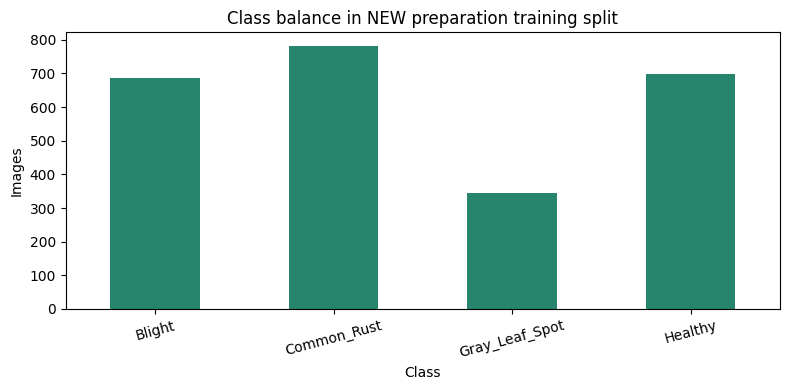

In [4]:
label_plot(cleaned, ROOT);

In [5]:
print(f'Training largest/smallest class ratio: {training_counts.max()/training_counts.min():.2f}')
print(f'The smallest training class is {training_counts.idxmin()}.')
print('An overall accuracy can hide poor recall for a smaller class. Report per-class scores and macro F1.')
print('Class weights can increase the loss contribution of small classes; choose their use on development evidence.')

Training largest/smallest class ratio: 2.28
The smallest training class is Gray_Leaf_Spot.
An overall accuracy can hide poor recall for a smaller class. Report per-class scores and macro F1.
Class weights can increase the loss contribution of small classes; choose their use on development evidence.


## 4. Model Design and Implementation
The task is four-class maize leaf image classification. The supplied website contains an EfficientNetB0 artifact. Its input contract is RGB, 224×224, float32 values in 0–255; scaling is inside the model. Custom CNN and MobileNetV2 were proposed but their training evidence is not in the supplied files.

This notebook implements and evaluates a preprocessing component. No classifier is trained here. The **new preparation split is not the original trained model's split**. Do not evaluate the already trained model on this split and call it an independent test.

## 5. Evaluation and Comparison
The executed tables, assertions and EDA figures above evaluate this preprocessing component. They are **not model accuracy or cross-validation results**.

The website metadata reports EfficientNetB0 accuracy **93.54%**, macro F1 **0.9132**, and **836 test images**. These values have not been recomputed from original predictions. Recover the original model notebooks, test manifest, predictions and per-fold scores before completing the final model-comparison section.

Do not substitute the new preparation split for the original test set. The supplied model may already have seen some of those images.

## 6. Ethical Considerations and Bias Mitigation
- Preserve raw images and record exclusions instead of deleting source evidence.
- Inspect the smaller Gray_Leaf_Spot class and report class-level performance when original evaluation evidence is recovered.
- Exact duplicate removal does not establish absence of near duplicates, same-plant overlap or source bias.
- Controlled dataset findings do not demonstrate performance on real farm photos.
- The website does not implement non-maize rejection. Scores are not guarantees or treatment advice.

## 7. AI Tool Usage Declaration and Transparency
ChatGPT/Codex assisted with the source inspection, notebook code, figures and explanations in this preparation package. The preprocessing cells were executed on the supplied archive and outputs were saved. Each member must rerun, inspect and understand their assigned code, document corrections, and declare their actual contribution. This assignment is proposed ownership; it is not evidence that this member authored the earlier model.

The original model's reported test metrics have not been independently reproduced here. Record actual training-related AI usage separately.

## 8. Reflections and Lessons Learned
**Observed technical lesson:** preprocessing decisions must be reproducible and traceable to the original files. A successful website and a preprocessing notebook do not replace model-comparison and cross-validation evidence.

**Personal reflection to complete after your own work:**
1. What did I run, verify or change?
2. What issue did I find and how did I resolve it?
3. Which output can I explain and what is its limitation?
4. What is my actual commit/PR link?

Do not present the prepared notes as a completed personal reflection.

## 9. References
- Supplied **Progress Review I - Data Preprocessing and EDA**: individual technique, implementation/output, EDA visualization and integrated pipeline requirements.
- Supplied **Final Evaluation - Documentation**: nine report sections, maximum 15 pages, group-ID PDF title.
- Supplied **Group Assignment Specification**: at least two models, tuning and k-fold cross-validation.
- Actual supplied `archive(1).zip`, copied unchanged to `data/raw/archive.zip`.
- Supplied website `model/model_info.json` and `app.py`, preserved under `website/`.
- Pillow API: https://pillow.readthedocs.io/en/stable/reference/Image.html
- scikit-learn StratifiedGroupKFold: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html

The proposal's IEEE dataset URL is a provenance lead. Its connection to this differently structured archive still needs confirmation.

### Viva practice
Why keep a fixed class order? What happens if prediction labels are reordered? Why calculate weights on training data only?

Use the actual outputs above to support your answers. Enter your real contribution and commit link after you review and run the notebook.